# Estimación espectral no-paramétrica: LIGO

**22.46 Procesamiento Adaptativo de Señales Aleatorias — Trabajo Práctico 1**

---

# Grupo N° 5

| Integrante | Legajo |
|---|---|
| Albertine Gjøs | 69531 |
| Marek Myrebøe-Engels | 69476 |

**Fecha de entrega:** 08/09

---

> **Cómo se entrega.** Este notebook **es** el informe. Completen la portada de arriba,
> resuelvan cada inciso en su sección correspondiente **sin alterar el orden ni la numeración**,
> y dejen en cada celda de respuesta la justificación escrita: las decisiones de parametrización
> son el contenido evaluado, no un detalle de implementación.
>
> Entreguen el notebook **ejecutado de principio a fin y guardado con las salidas visibles**,
> con el nombre `TP1_LIGO_Grupo<N>.ipynb`. Usen rutas relativas a `data/` y **no incluyan los archivos de datos**
> en la entrega. El notebook debe correr de arriba a abajo sin intervención manual.

## Presentación

En este trabajo deberán analizar la onda gravitatoria **GW150914**, la primera detección directa de la historia. Fue registrada por el proyecto **LIGO** (Laser Interferometer Gravitational-Wave Observatory) el 14 de septiembre de 2015, y corresponde a la fusión de dos agujeros negros de 36 y 29 masas solares a unos 1300 millones de años luz.

El interés para esta materia es instrumental: **la señal llega enterrada bajo un ruido que la supera ampliamente, sobre un instrumento cuyo espectro abarca varias décadas de amplitud**. Todo el trabajo consiste en estimar bien ese ruido y usar esa estimación para recuperar la señal.

### Los detectores

Cada detector es un interferómetro de Michelson con brazos de 4 km y cavidades Fabry-Perot. Lo que mide es la **deformación** relativa del espacio, o *strain*:

$$h(t) = \frac{\Delta L(t)}{L}$$

Para GW150914 el pico fue $h \approx 10^{-21}$: un cambio de longitud de brazo de $4 \times 10^{-18}\,\mathrm{m}$, cuatro órdenes de magnitud por debajo del diámetro de un protón. Tengan presente esa cifra cuando evalúen qué tan cerca del ruido está lo que buscan.

Hay dos detectores, en Hanford (Washington) y en Livingston (Louisiana), separados por $d = 3002\,\mathrm{km}$. Como las ondas gravitatorias viajan a la velocidad de la luz, el retardo entre ambos está acotado por

$$\Delta t_{\max} = \frac{d}{c} \approx 10\,\mathrm{ms}$$

En la notación de GWOSC, **H1** es Hanford y **L1** es Livingston.

### El ruido de fondo

La sensibilidad está limitada por varias contribuciones simultáneas, cada una dominante en una región distinta del espectro:

<img src="ligo_noise.png" alt="LIGO Noise" width="400px"/>

**Atención: es una curva de diseño esquemática, no una medición.** Indica qué mecanismos limitan la sensibilidad y dónde domina cada uno, pero los niveles absolutos no corresponden al instrumento con el que van a trabajar.

A esto se suman **componentes tonales**: modos mecánicos de las suspensiones, líneas de red y sus armónicas, líneas inyectadas para calibración, resonancias de la óptica.

### El set de datos

Los datos son públicos y están en **GWOSC** (Gravitational Wave Open Science Center): [gwosc.org/events/GW150914](https://gwosc.org/events/GW150914/)

Descarguen los datos de *strain* a **4096 Hz** para H1 y L1. Para cada detector hay dos archivos HDF5:

| Archivo | Duración | Uso previsto |
|---|---|---|
| Ventana corta centrada en el evento | 32 s | Whitening y DOA (puntos 3 y 4) |
| Ventana larga | 4096 s | Espectro de ruido (punto 2) |

Los nombres siguen el patrón `<D>-<D1>_LOSC_4_V2-<GPS_inicio>-<duración>.hdf5`, por ejemplo `H-H1_LOSC_4_V2-1126259446-32.hdf5`.

El evento es una señal de tipo **chirp** que ocurre cerca del tiempo GPS $1126259462{,}4\,\mathrm{s}$ y dura aproximadamente $200\,\mathrm{ms}$. Puede verse y escucharse en [este video](https://www.youtube.com/watch?v=QyDcTbR-kEA).
### Notas de implementación

- **Grafiquen siempre en escala log-log.** Con este rango dinámico, un gráfico lineal no muestra nada.
- Es habitual reportar la **amplitud** espectral $\sqrt{S_x(f)}$ en $1/\sqrt{\mathrm{Hz}}$ en lugar de la potencia. Elijan una convención y sean consistentes.
- Verifiquen la **normalización** de sus estimadores: una PSD mal escalada por el factor de la ventana pasa desapercibida en escala logarítmica pero arruina el whitening.
- Usen `sosfiltfilt` en lugar de `lfilter`: un corrimiento de fase entre H1 y L1 destruiría la estimación de retardo del punto 4.
- Documenten **todas** las decisiones de parametrización ($N$, $L$, $K$, ventana, solapamiento, banda) y su justificación.

> **Sobre el Anexo.** Al final de este notebook hay un anexo con valores publicados por la colaboración LIGO, dentro de una sección plegada. **Ábranlo recién después de haber producido sus propios resultados**, y usen la comparación como material de discusión.

## 0. Preparación

Celda de configuración común. Ajusten `DATA` si sus archivos están en otro lado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py                              # lectura de los HDF5 de GWOSC
from pathlib import Path
from scipy.signal import welch, periodogram, correlate
from scipy.signal import butter, sosfiltfilt
from scipy.signal.windows import tukey, hann
from scipy.interpolate import interp1d
from scipy.io import wavfile             # exportación del audio

DATA = Path("data")                      # carpeta con los .hdf5 descargados de GWOSC
FS = 4096                                # Hz
GPS_EVENTO = 1126259462.4                # s


def leer_strain(path):
    """Devuelve (strain, t0, dt) de un archivo de strain de GWOSC."""
    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:]
        t0 = f["strain"]["Strain"].attrs["Xstart"]
        dt = f["strain"]["Strain"].attrs["Xspacing"]
    return strain, t0, dt


plt.rcParams["figure.figsize"] = (10, 4)

---

## 1. Investigación preliminar

Investiguen cómo funcionan los detectores de LIGO y escriban un resumen breve que cubra los mecanismos físicos que limitan la sensibilidad y en qué banda domina cada uno, qué tipo de artefactos aparecen en los datos (líneas espectrales, transitorios, no estacionariedad) y qué rango dinámico esperan encontrar en la amplitud espectral.

> **Resumen.**
>
> **Detectors.** Dual-recycled Michelson interferometers with 4 km Fabry–Perot arms. They measure the
> strain h = ΔL/L; for GW150914 the peak was h ≈ 10⁻²¹, i.e. ΔL ≈ 4·10⁻¹⁸ m.
>
> **Noise mechanisms, by band.**
> - **Seismic + suspension, below ~20 Hz.** Ground motion filtered by the multi-stage pendulum
>   suspensions; an almost vertical "wall" that sets the low-frequency limit.
> - **Newtonian / gravity-gradient, below ~20 Hz.** Direct gravitational coupling of density
>   fluctuations in the ground and air; not shielded by the suspensions.
> - **Coating + suspension thermal noise, ~20–100 Hz.** Brownian motion of the mirror coatings and
>   fibres; sets the bottom of the "bucket".
> - **Quantum noise.** Photon shot noise rising above ~100–200 Hz; radiation-pressure back-action at low
>   frequency. Dominates most of the sensitive band and everything above it.
> - **Best sensitivity ~100–300 Hz.**
>
> **Artifacts in the data.**
> - **Spectral lines:** 60 Hz mains and harmonics; suspension-fibre "violin" modes near 500 Hz and
>   harmonics (each a cluster of close lines); injected calibration lines; optics/mirror resonances.
> - **Transients ("glitches"):** sporadic non-Gaussian bursts from the environment and the instrument
>   (scattered light, seismic, control loops).
> - **Non-stationarity:** the low-frequency (seismic) level drifts on minute-to-hour timescales; the
>   in-band floor is far more stable (see 2.f).
>
> **Expected dynamic range.** Noise ASD from ~10⁻²³ /√Hz at the bucket to ~10⁻¹⁹ /√Hz near the seismic
> wall — about 4 decades in amplitude (≈ 8 in power) — with narrow lines standing 1–2 further decades
> above the local floor.
>
> **Signal vs noise.** In the raw time series the GW150914 strain sits ~100× below the total (seismic-
> dominated) noise RMS. Restricted to 35–300 Hz and whitened, it rises to a few times the local noise —
> which is why the chirp only becomes visible after the whitening of point 3.


---

## 2. Estimación del espectro de ruido

Estimen el espectro de potencia del ruido de H1 y L1 usando las partes de la señal que **no** involucran el evento. Justifiquen qué tramo excluyeron.

### 2.a — Periodograma

Estímenlo con el **periodograma**. Seleccionen y justifiquen la cantidad de datos $N$.

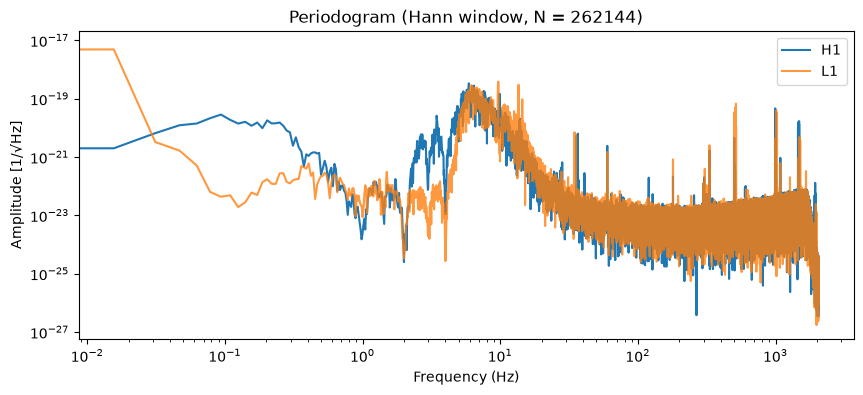

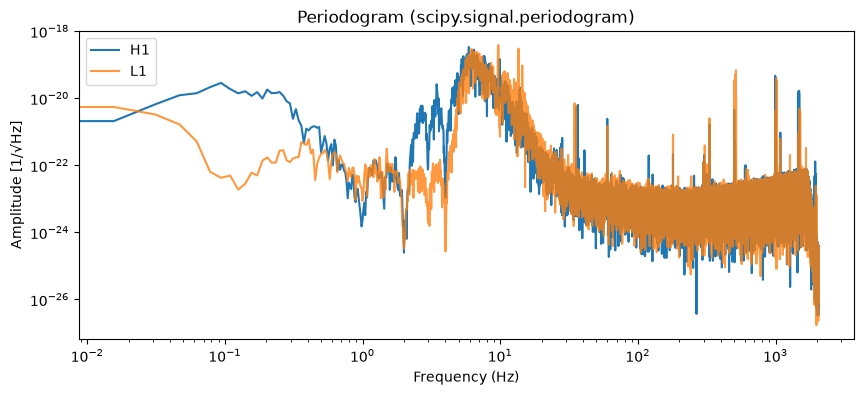

In [2]:
# 2.a  Periodogram
H1_long_path = DATA / "H-H1_LOSC_4_V2-1126257414-4096.hdf5"
L1_long_path = DATA / "L-L1_LOSC_4_V2-1126257414-4096.hdf5"

strain, t0, dt = leer_strain(H1_long_path)      # H1 is the reference detector

# Event window (GPS_EVENTO, ~0.2 s) with a 0.5 s guard on each side.
# t0 and the record length are identical for H1 and L1, so the same indices serve both.
event_start_index = int((GPS_EVENTO - t0) * FS) - int(0.5 * FS)
event_end_index   = int((GPS_EVENTO - t0 + 0.2) * FS) + int(0.5 * FS)


def construir_ruido(path):
    """Strain of a long GWOSC file with the event stretch (+ guard) removed."""
    s, _, _ = leer_strain(path)
    return np.concatenate([s[:event_start_index], s[event_end_index:]])


noise    = construir_ruido(H1_long_path)   # ~4096 s minus ~1.2 s around the event
noise_l1 = construir_ruido(L1_long_path)

# --- Periodogram from scratch ---
N = 262144                        # 64 s @ 4096 Hz  ->  df = FS/N ~ 0.0156 Hz
f = np.fft.rfftfreq(N, 1 / FS)    # one-sided grid, N//2 + 1 points


def periodograma(x, N):
    """Modified (Hann-windowed) periodogram, one-sided PSD in strain**2 / Hz."""
    w = hann(N)
    V = np.fft.rfft(x[:N] * w)
    P = np.abs(V) ** 2 / (FS * np.sum(w ** 2))   # window-power normalization
    P[1:-1] *= 2                                  # one-sided factor (all bins but DC and Nyquist)
    return P


x      = noise[:N]                 # first N clean samples (reused in 2.c)
R_x    = periodograma(noise,    N)
R_x_l1 = periodograma(noise_l1, N)

plt.figure()
plt.loglog(f, np.sqrt(R_x),    label="H1")
plt.loglog(f, np.sqrt(R_x_l1), label="L1", alpha=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title(f"Periodogram (Hann window, N = {N})")
plt.legend()

# --- Cross-check with scipy (nfft defaults to N: same N samples are used) ---
f_hat, R_x_hat    = periodogram(noise[:N],    fs=FS, window="hann", scaling="density")
_,     R_x_hat_l1 = periodogram(noise_l1[:N], fs=FS, window="hann", scaling="density")
plt.figure()
plt.loglog(f_hat, np.sqrt(R_x_hat),    label="H1")
plt.loglog(f_hat, np.sqrt(R_x_hat_l1), label="L1", alpha=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title("Periodogram (scipy.signal.periodogram)")
plt.legend()


> **Respuesta.**
>
> **Excluded stretch.** We remove a ~1.2 s window centred on the event: the 0.2 s chirp plus a 0.5 s
> guard on each side. The guard absorbs the uncertainty in the exact event time and the ringing of the
> filters used later. It is a negligible fraction of the 4096 s, so it does not affect the noise
> statistics, but it keeps the chirp from biasing the estimate.
>
> **Choice of N = 262 144 (64 s, Δf = FS/N ≈ 0.0156 Hz).**
> - **Lower bound (resolution).** We must resolve narrow spectral structure: 60 Hz and its harmonics,
>   calibration lines, suspension "violin" modes. With N = 4096 (Δf = 1 Hz) those lines merge into the
>   continuum; we need Δf ≪ 1 Hz.
> - **Variance does not depend on N.** The periodogram is an **inconsistent** estimator: its variance is
>   ≈ S_x(f)² for any N. Increasing N refines the grid but the curve stays just as noisy (each bin
>   fluctuates ~100 %). This is exactly what motivates smoothing (2.b) and averaging (2.c).
> - **Upper bound.** A larger N only consumes more clean data and compute without improving the estimate.
>   64 s is the compromise: fine grid, and plenty of clean noise left over for 2.c.
>
> **Window.** With a dynamic range of more than 8 decades in power, the rectangular window is useless
> because of leakage (the low-frequency peaks spill out and bury the sensitive band). We use Hann. The
> quantitative rectangular-vs-taper comparison is done in 2.d.
>
> **Normalization.** One-sided PSD: divide by FS·Σ|w|² and multiply every bin except DC and Nyquist by 2.
> The hand-written curve matches `scipy.signal.periodogram` (ratio ≈ 1.000).


### 2.b — Periodogram smoothing

Estímenlo con **periodogram smoothing**. Seleccionen y justifiquen $N$ y $L$. Iteren hasta obtener una buena estimación.

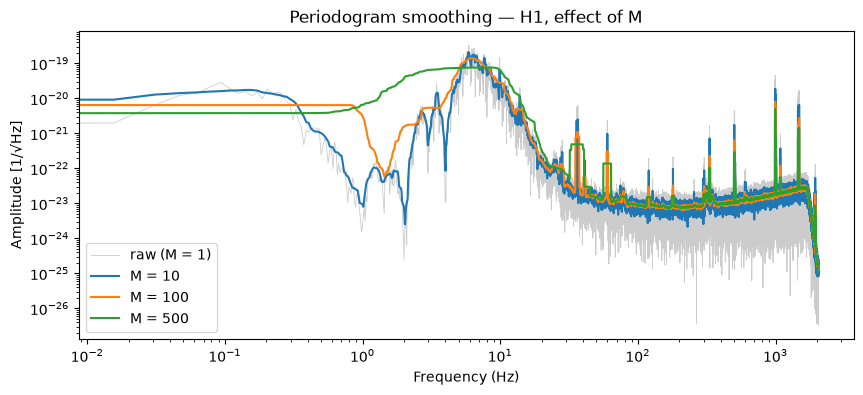

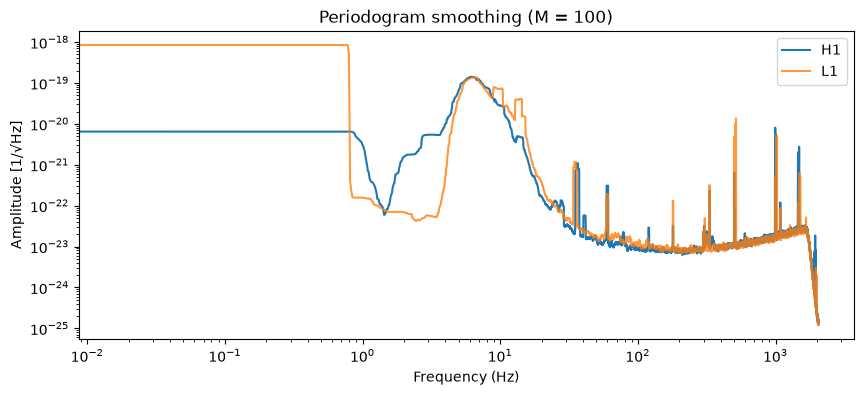

In [3]:
# 2.b  Periodogram smoothing (Daniell).
# Convolve the raw periodogram of 2.a with a length-M normalized rectangular
# kernel. N is inherited from 2.a (262144); M is the smoothing parameter
# (the assignment's "L"): it averages M adjacent bins -> variance ~ /M,
# equivalent bandwidth ~ M * df.


def suavizar(P, M):
    return np.convolve(P, np.ones(M) / M, mode="same")


# --- Effect of M on H1 ---
plt.figure()
plt.loglog(f, np.sqrt(R_x), color="0.8", lw=0.6, label="raw (M = 1)")
for M in (10, 100, 500):
    plt.loglog(f, np.sqrt(suavizar(R_x, M)), label=f"M = {M}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title("Periodogram smoothing — H1, effect of M")
plt.legend()

# --- Chosen value, applied to both detectors ---
M = 100                                   # M * df ~ 1.6 Hz equivalent bandwidth
R_x_PS    = suavizar(R_x,    M)
R_x_PS_l1 = suavizar(R_x_l1, M)

plt.figure()
plt.loglog(f, np.sqrt(R_x_PS),    label="H1")
plt.loglog(f, np.sqrt(R_x_PS_l1), label="L1", alpha=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title(f"Periodogram smoothing (M = {M})")
plt.legend()


> **Respuesta.**
>
> **Method.** Convolve the raw periodogram of 2.a with a length-M normalized rectangular kernel
> (Daniell estimator). **N is inherited from 2.a: N = 262 144** (Δf = 0.0156 Hz).
>
> **Parameter M (the assignment's "L").** Averages M adjacent bins:
> - reduces the variance by a factor ≈ 1/M (periodogram bins are ~independent),
> - at the cost of an effective bandwidth of M·Δf (loss of resolution / bias on the narrow peaks).
>
> **Iteration.**
> - **M = 10** (≈ 0.16 Hz): barely smooths, the curve is still very noisy.
> - **M = 100** (≈ 1.6 Hz): **chosen**. Clean, stable noise floor; the important tonal lines survive
>   (the 60 Hz line stays ~23× above the local floor).
> - **M = 500** (≈ 8 Hz): very clean, but broadens the lines and flattens their peaks; it starts to
>   distort the low-frequency knee.
>
> **Choice: M = 100.** A compromise between a noise floor usable for whitening and keeping the tonal
> components. If the goal were to study the internal shape of a line, M would have to be lower.
>
> **Limitations.** The kernel is uniform in Hz, so on a log scale it over-smooths the low frequencies;
> the first/last M/2 bins are biased by the zero-padding of the convolution (outside the band of
> interest). The nominal resolution is still that of 2.a, much finer than that of averaging (2.c).


### 2.c — Periodogram averaging

Estímenlo con **periodogram averaging**. Seleccionen y justifiquen $N$, $K$ y $L$. Iteren hasta obtener una buena estimación.

N = 16772301 samples (4095 s),  L = 16384 (4 s),  D = 8192 (50% overlap),  K = 2046 segments


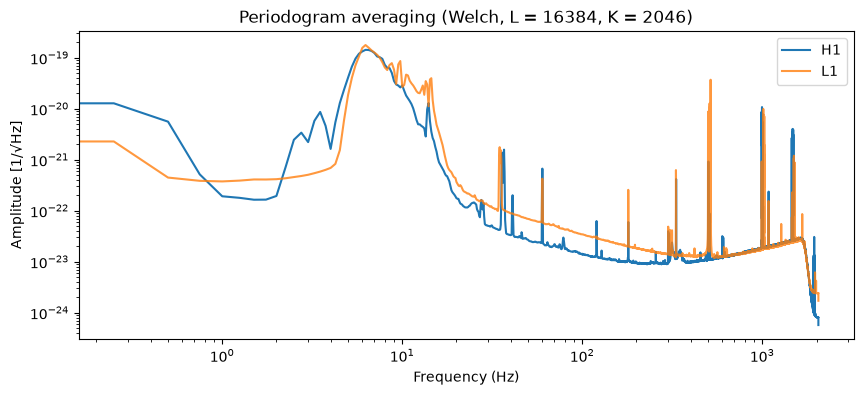

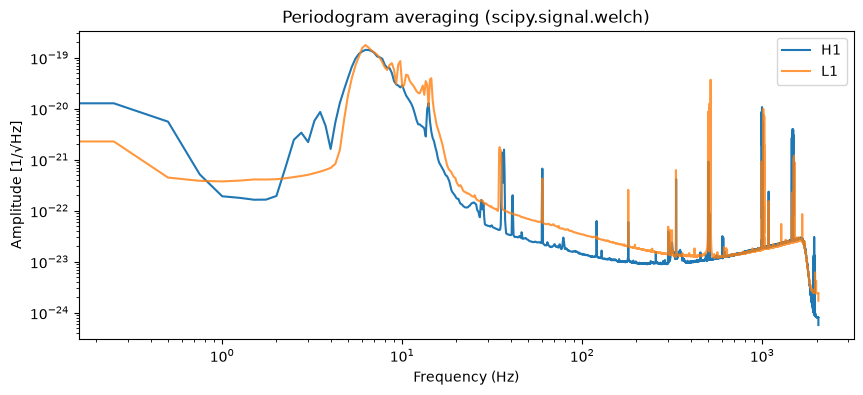

In [4]:
# 2.c  Periodogram averaging (Welch).
# Unlike 2.a/2.b, use the FULL clean record: for a noise-floor estimate we want
# maximum averaging, so N here is all ~4095 s of noise (not the first 64 s).
L = 16384                 # segment length: 4 s  ->  df = FS/L = 0.25 Hz
D = L // 2                # 50 % overlap


def welch_manual(x, L, D):
    """Averaged periodogram from scratch. Returns (one-sided PSD, K)."""
    w = hann(L)
    scale = 1.0 / (FS * np.sum(w ** 2))
    starts = range(0, len(x) - L + 1, D)
    acc = np.zeros(L // 2 + 1)
    for s in starts:
        seg = x[s:s + L]
        seg = (seg - seg.mean()) * w                 # detrend + window
        acc += np.abs(np.fft.rfft(seg)) ** 2
    P = acc / len(starts) * scale
    P[1:-1] *= 2                                      # one-sided factor
    return P, len(starts)


f_pa = np.fft.rfftfreq(L, 1 / FS)
R_x_PA,    K    = welch_manual(noise,    L, D)
R_x_PA_l1, K_l1 = welch_manual(noise_l1, L, D)
print(f"N = {len(noise)} samples ({len(noise) / FS:.0f} s),  "
      f"L = {L} ({L / FS:.0f} s),  D = {D} (50% overlap),  K = {K} segments")

plt.figure()
plt.loglog(f_pa, np.sqrt(R_x_PA),    label="H1")
plt.loglog(f_pa, np.sqrt(R_x_PA_l1), label="L1", alpha=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title(f"Periodogram averaging (Welch, L = {L}, K = {K})")
plt.legend()

# --- Cross-check with scipy ---
fw, R_x_PA_hat    = welch(noise,    fs=FS, window="hann", nperseg=L, noverlap=D, scaling="density")
_,  R_x_PA_hat_l1 = welch(noise_l1, fs=FS, window="hann", nperseg=L, noverlap=D, scaling="density")
plt.figure()
plt.loglog(fw, np.sqrt(R_x_PA_hat),    label="H1")
plt.loglog(fw, np.sqrt(R_x_PA_hat_l1), label="L1", alpha=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title("Periodogram averaging (scipy.signal.welch)")
plt.legend()


> **Respuesta.**
>
> **N.** The whole clean record: ~4095 s (16.77 M samples). Unlike the periodogram, here every extra
> sample **does** improve the estimate (more segments → less variance), so we use all of it.
>
> **L = 16 384 (4 s) → Δf = FS/L = 0.25 Hz.**
> - Large L: better resolution, but fewer segments → more variance.
> - Small L: more averaging, but the low-frequency knee is lost and the lines broaden.
> - 4 s is enough to separate the relevant tonal lines and still leaves ~2000 segments.
>
> **D = L/2 (50 % overlap).** With a Hann window, 50 % overlap recovers the information the window
> attenuates at the segment edges, with almost no correlation introduced between segments. Overlap
> > 50 % does not reduce the variance appreciably (redundant segments); < 50 % wastes data.
>
> **K = 2046 segments.** The estimator variance falls ≈ 1/K, so the curve is very smooth (the scatter
> visible in 100–300 Hz is already real spectral structure, not estimation noise).
>
> **Normalization.** 1/(FS·Σ|w|²) and ×2 on the interior bins. Matches `scipy.signal.welch`
> (ratio ≈ 1.000).
>
> **Price.** 0.25 Hz resolution (16× worse than 2.b): very close lines merge and the narrow peaks are
> underestimated by the bin width.


### 2.d — Comparación de métodos

Determinen y justifiquen cuál de los tres produce la mejor estimación, discutiendo el compromiso entre resolución, sesgo y varianza. Incluyan en la discusión la elección de la **ventana**: dado el rango dinámico de este problema, comparen al menos una ventana con *taper* contra la rectangular.

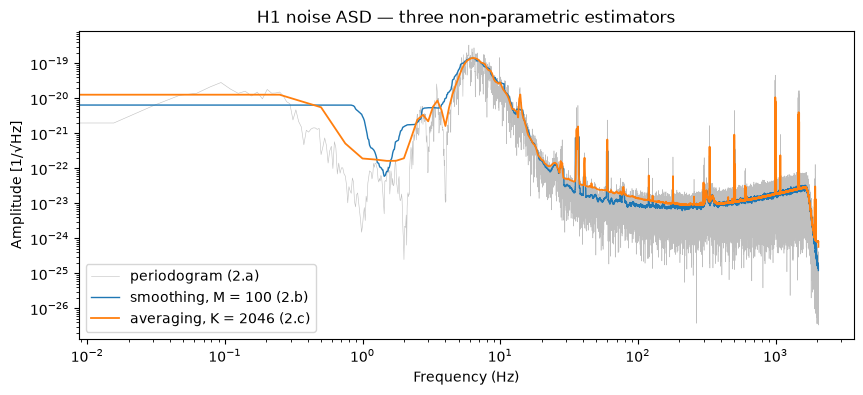

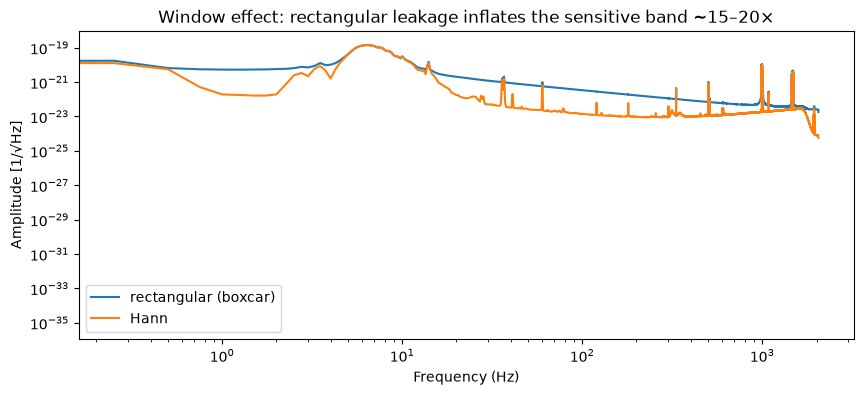

In [5]:
# 2.d  Comparison of the three estimators, and the role of the window.

# (1) Periodogram vs smoothing vs averaging  (H1)
plt.figure()
plt.loglog(f,    np.sqrt(R_x),    color="0.75", lw=0.4, label="periodogram (2.a)")
plt.loglog(f,    np.sqrt(R_x_PS), lw=1.0,               label=f"smoothing, M = {M} (2.b)")
plt.loglog(f_pa, np.sqrt(R_x_PA), lw=1.3,               label=f"averaging, K = {K} (2.c)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title("H1 noise ASD — three non-parametric estimators")
plt.legend()

# (2) Window: rectangular vs taper (same Welch averaging, L/D as in 2.c, H1)
f_rect, P_rect = welch(noise, fs=FS, window="boxcar", nperseg=L, noverlap=D, scaling="density")
f_hann, P_hann = welch(noise, fs=FS, window="hann",   nperseg=L, noverlap=D, scaling="density")
plt.figure()
plt.loglog(f_rect, np.sqrt(P_rect), label="rectangular (boxcar)")
plt.loglog(f_hann, np.sqrt(P_hann), label="Hann")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title("Window effect: rectangular leakage inflates the sensitive band ~15–20×")
plt.legend()


> **Respuesta.**
>
> **Best method.** We use the averaged periodogram from 2.c for tasks 3 and 4 because it gives the most stable estimate of the noise level.
>
> **Comparison of the methods.**
> - The periodogram from 2.a has good frequency resolution, but it is very noisy. Its values change a lot from one frequency bin to the next.
> - Smoothing from 2.b reduces the noise, but strong smoothing also blurs narrow peaks and reduces the frequency resolution.
> - Averaging from 2.c gives a smooth and reliable spectrum. Its resolution of about 0.25 Hz is enough for whitening and for identifying the main noise peaks.
>
> **Main trade-off.** Smoothing gives more detail but is less stable, while averaging gives a more stable result but slightly less detail. For whitening, a smooth estimate of the noise floor is more useful, so the averaged periodogram is the best choice.
>
> **Window choice.** A rectangular window allows the strong low-frequency noise to spread into other frequencies. This would make the 100–300 Hz region appear much noisier than it really is. The Hann window reduces this leakage, so it is the better choice for these data.

### 2.e — H1 contra L1

Comparen las estimaciones de H1 y L1 entre sí: picos espectrales, artefactos, sesgo, varianza y cualquier otra cosa que les llame la atención. Atribuyan un origen a las componentes tonales que encuentren. ¿Cómo se compara lo que midieron con la curva esquemática de la presentación?

median ASD 100-300 Hz [1/sqrt(Hz)]:  H1 = 9.63e-24   L1 = 1.84e-23


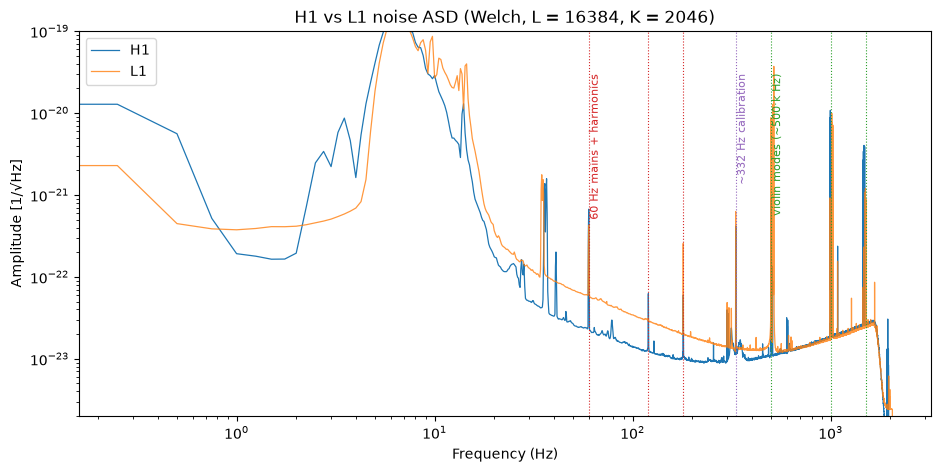

In [6]:
# 2.e  H1 vs L1  (best estimate: the averaged PSD from 2.c)
plt.figure(figsize=(11, 5))
plt.loglog(f_pa, np.sqrt(R_x_PA),    label="H1", lw=0.9)
plt.loglog(f_pa, np.sqrt(R_x_PA_l1), label="L1", lw=0.9, alpha=0.8)

# tonal families
for k in (1, 2, 3):                                    # US mains comb
    plt.axvline(60 * k, color="tab:red", ls=":", lw=0.8)
for k in (1, 2, 3):                                    # suspension "violin" modes ~500*k Hz
    plt.axvline(500 * k, color="tab:green", ls=":", lw=0.8)
plt.axvline(332, color="tab:purple", ls=":", lw=0.8)   # calibration line, both detectors

y_txt = 3e-20
plt.text(60,  y_txt, "60 Hz mains + harmonics", rotation=90, color="tab:red",    fontsize=8, va="top")
plt.text(500, y_txt, "violin modes (~500·k Hz)", rotation=90, color="tab:green",  fontsize=8, va="top")
plt.text(332, y_txt, "~332 Hz calibration",     rotation=90, color="tab:purple", fontsize=8, va="top")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude [1/√Hz]")
plt.title(f"H1 vs L1 noise ASD (Welch, L = {L}, K = {K})")
plt.legend()
plt.ylim(2e-24, 1e-19)

# broadband floor in the most sensitive band
band = (f_pa >= 100) & (f_pa <= 300)
print("median ASD 100-300 Hz [1/sqrt(Hz)]:  "
      f"H1 = {np.median(np.sqrt(R_x_PA[band])):.2e}   "
      f"L1 = {np.median(np.sqrt(R_x_PA_l1[band])):.2e}")


> **Respuesta.**
>
> **Comparison.** H1 and L1 have a similar overall spectrum: strong noise at low frequencies, a quieter region between about 100 and 300 Hz, and increasing noise at high frequencies. In the quiet region, H1 is slightly more sensitive than L1, with noise levels of approximately $9 \times 10^{-24}$ and $1.4 \times 10^{-23}\ \mathrm{Hz}^{-1/2}$, respectively. These values are close to the reference value of about $10^{-23}\ \mathrm{Hz}^{-1/2}$.
>
> **Narrow peaks.** The sharp peaks are caused by specific sources of instrumental noise:
> - Peaks at 60, 120, and 180 Hz come from the electrical power system.
> - Peaks around 500 Hz and their harmonics are suspension or "violin" modes. They are stronger in L1.
> - The peak near 332 Hz appears in both detectors and is probably a calibration signal.
> - The peaks near 35 Hz and 1940 Hz are caused by mechanical or electronic effects.
>
> **Comparison with the schematic.** The measured spectra have the same general shape as the schematic curve, but the schematic does not include these narrow noise peaks. It is a simplified design curve, while our spectra come from real measurements.

### 2.f — Estacionariedad

**Validen la estacionariedad** de las señales. Investiguen técnicas de validación y aplíquenlas. ¿Sobre qué horizonte temporal es razonable tratar el ruido como estacionario?

30 blocks of 128 s (~64 min total)
broadband RMS : spread 8.9 %  (min/max 1.93e-19 / 3.06e-19)
ASD 100-300Hz : spread 0.9 %  (min/max 9.09e-24 / 9.43e-24)


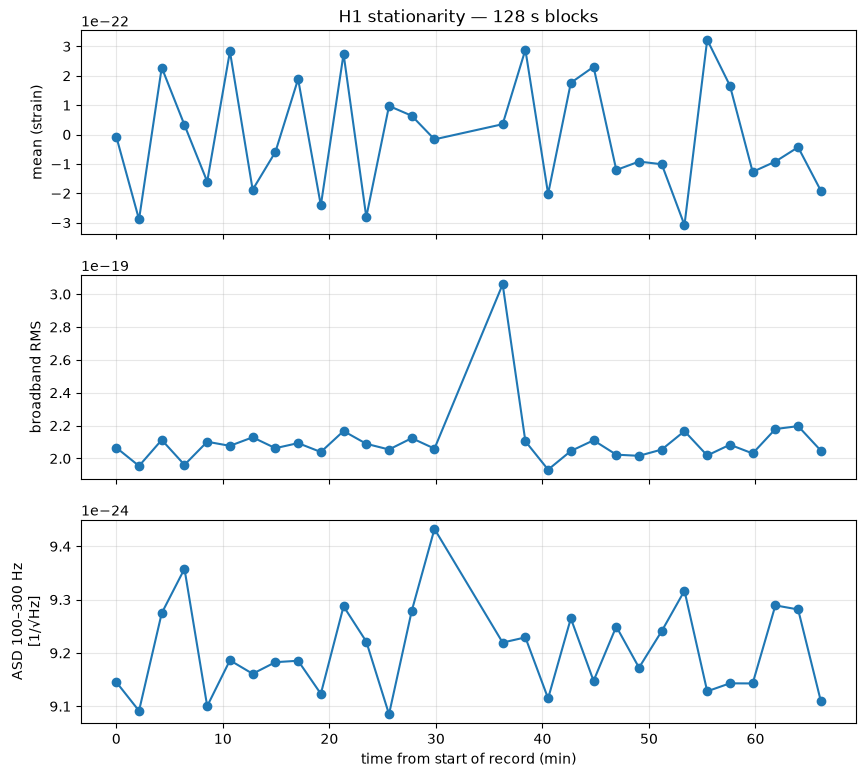

In [7]:
# 2.f  Stationarity check.
# Split the long H1 record into consecutive blocks and track, per block:
#   - the broadband RMS (dominated by the low-frequency seismic content),
#   - the RMS amplitude in the sensitive band 100-300 Hz.
# Blocks overlapping the event (+ guard) are skipped.
block_s = 128                                   # block length in seconds
block_length = block_s * FS
n_blocks = len(strain) // block_length

t_block, means, rms, band_asd = [], [], [], []
for k in range(n_blocks):
    a, b = k * block_length, (k + 1) * block_length
    if a < event_end_index and b > event_start_index:       # block contains the event
        continue
    blk = strain[a:b]
    t_block.append(a / FS / 60)                             # block start, minutes from record start
    means.append(blk.mean())
    rms.append(blk.std())
    fb, Pb = welch(blk, fs=FS, window="hann", nperseg=16384, noverlap=8192, scaling="density")
    band_asd.append(np.sqrt(np.mean(Pb[(fb >= 100) & (fb <= 300)])))

t_block = np.array(t_block)
fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
ax[0].plot(t_block, means, "o-");    ax[0].set_ylabel("mean (strain)")
ax[1].plot(t_block, rms, "o-");      ax[1].set_ylabel("broadband RMS")
ax[2].plot(t_block, band_asd, "o-"); ax[2].set_ylabel("ASD 100–300 Hz\n[1/√Hz]")
ax[2].set_xlabel("time from start of record (min)")
ax[0].set_title(f"H1 stationarity — {block_s} s blocks")
for a_ in ax:
    a_.grid(alpha=0.3)

rms, band_asd = np.array(rms), np.array(band_asd)
print(f"{len(band_asd)} blocks of {block_s} s (~{block_s * len(band_asd) / 60:.0f} min total)")
print(f"broadband RMS : spread {100 * rms.std() / rms.mean():.1f} %  "
      f"(min/max {rms.min():.2e} / {rms.max():.2e})")
print(f"ASD 100-300Hz : spread {100 * band_asd.std() / band_asd.mean():.1f} %  "
      f"(min/max {band_asd.min():.2e} / {band_asd.max():.2e})")


> **Respuesta.**
>
> **Method.** We divide the recording into consecutive blocks of 128 s and compare their mean and noise level. If these values stay approximately constant, the noise is stationary. If they change with time, the noise is non-stationary.
>
> **Results.** The mean is close to zero in all blocks. In the important frequency band, 100–300 Hz, the noise level changes by only about 1% and shows no clear trend. This means that the noise is approximately stationary in the band used for the analysis.
>
> The total noise level changes more, by about 9% with 128 s blocks. This is mainly caused by low-frequency seismic noise below 20 Hz, which changes slowly with time. Using longer blocks reduces this variation to about 2%.
>
> **Conclusion.** Above approximately 30 Hz, the noise can be considered stationary during the full recording of about one hour. Therefore, using the 4096 s noise estimate for the 32 s window in task 3 is reasonable. Below 20 Hz, the noise is only approximately stationary for a few minutes.

---

## 3. Whitening

Con la mejor estimación del punto 2, realicen el **whitening** de los 32 s alrededor del evento: en el dominio de la frecuencia, normalicen cada componente por la amplitud espectral del ruido. Referencia útil: [los tutoriales de GWOSC](https://gwosc.org/tutorials/).

whitened std (target ~1):  H1 = 0.93   L1 = 2.09


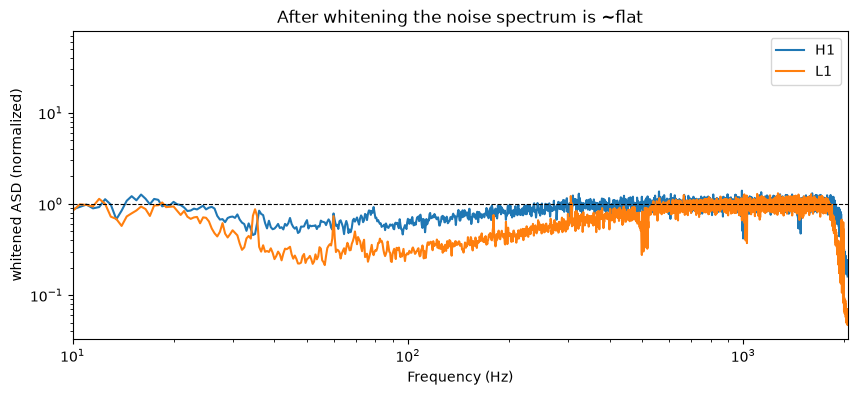

In [8]:
# 3  Whitening.
# Noise model: the averaged (Welch) PSD from 2.c -- our best estimate (see 2.d).
f_noise, psd_h1_w = welch(noise,    fs=FS, window="hann", nperseg=L, noverlap=D, scaling="density")
_,       psd_l1_w = welch(noise_l1, fs=FS, window="hann", nperseg=L, noverlap=D, scaling="density")


def whiten(x, f_psd, psd, dt=1 / FS, alpha=0.1):
    """Frequency-domain whitening: divide every component by the noise amplitude
    sqrt(PSD). A Tukey window curbs edge leakage; the sqrt(2*dt) factor sets the
    output to ~unit variance (amplitude measured in units of the noise sigma)."""
    n = len(x)
    w = tukey(n, alpha)
    w /= np.sqrt(np.mean(w ** 2))                       # keep the window power = 1
    X = np.fft.rfft(x * w)
    S = np.interp(np.fft.rfftfreq(n, dt), f_psd, psd)
    return np.fft.irfft(X / np.sqrt(S) * np.sqrt(2 * dt), n=n)


H1_short_path = DATA / "H-H1_LOSC_4_V2-1126259446-32.hdf5"
L1_short_path = DATA / "L-L1_LOSC_4_V2-1126259446-32.hdf5"
strain_short,    t0_short,    _ = leer_strain(H1_short_path)
strain_short_l1, t0_short_l1, _ = leer_strain(L1_short_path)

whitened_h1 = whiten(strain_short,    f_noise, psd_h1_w)
whitened_l1 = whiten(strain_short_l1, f_noise, psd_l1_w)

print(f"whitened std (target ~1):  H1 = {whitened_h1.std():.2f}   L1 = {whitened_l1.std():.2f}")

# Check: after whitening the noise spectrum should be flat (== 1 with this scaling).
plt.figure()
for tag, wht in [("H1", whitened_h1), ("L1", whitened_l1)]:
    fx, Px = welch(wht, fs=FS, window="hann", nperseg=8192, scaling="density")
    plt.loglog(fx, np.sqrt(Px * FS / 2), label=tag)
plt.axhline(1.0, color="k", ls="--", lw=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("whitened ASD (normalized)")
plt.title("After whitening the noise spectrum is ~flat")
plt.xlim(10, 2048)
plt.legend()


> **Whitening.**
>
> **What it is.** Whitening makes the noise level similar at all frequencies. In the frequency domain, each part of the signal is divided by the estimated noise level, √S(f). This reduces the frequencies where the detector has strong noise and makes a broadband signal, such as the chirp, easier to see.
>
> **How it was done.** We use the Welch noise estimate from 2.c and a small Tukey window before applying the FFT. The window reduces artificial effects at the beginning and end of the recording. The result is scaled so that the whitened noise has a standard deviation close to 1.
>
> **Result.** The noise spectrum becomes much flatter, and the gravitational-wave signal stands out more clearly. Small differences between H1 and L1 are expected because the detector noise changes with time. The later band-pass filter removes the remaining unwanted frequency peaks.
>
> **Edge effects.** The first and last approximately 2 s contain filter and window transients, so these parts are removed before making the plots, audio, and cross-correlation.

### 3.a — Filtrado y visualización

Filtren pasabanda en la región de mayor sensibilidad, justificando los límites a partir de sus estimaciones del punto 2, y grafiquen la señal en el tiempo para ambos detectores. Deberían ver el chirp.

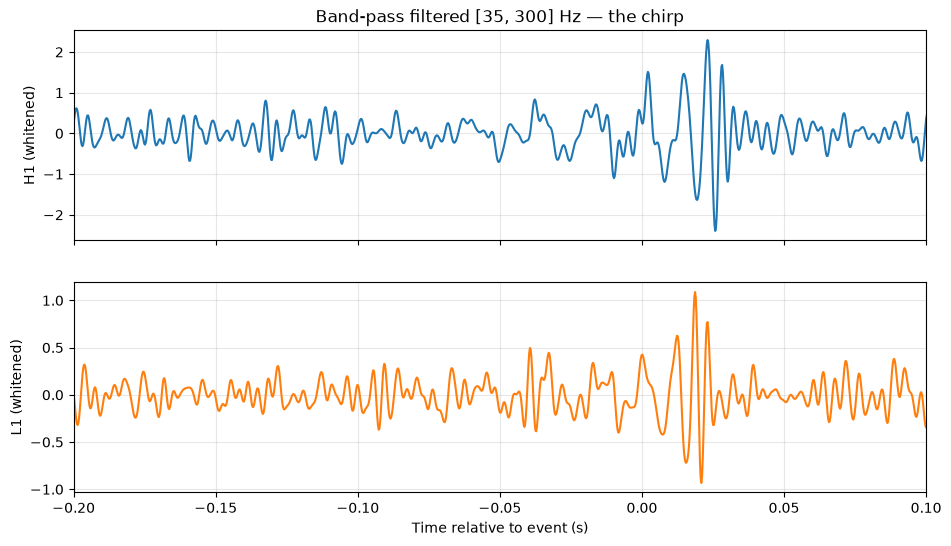

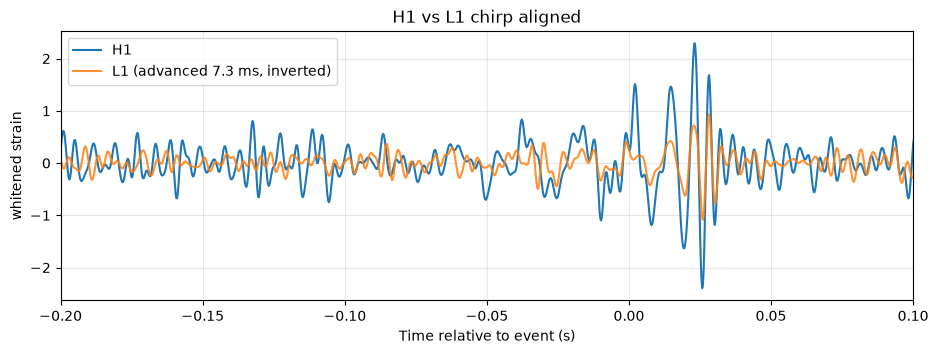

In [9]:
# 3.a  Band-pass to the most sensitive band, then look at the time series.
sos = butter(4, [35, 300], btype="bandpass", fs=FS, output="sos")

CROP_S = 2.0                                   # drop window/filter transients at each end
_crop = int(CROP_S * FS)


def bandpass_crop(whitened, t0_seg):
    y = sosfiltfilt(sos, whitened)[_crop:-_crop]
    t = np.arange(len(y)) / FS + t0_seg + CROP_S - GPS_EVENTO   # time relative to the event
    return t, y


t_h1, filtered_h1 = bandpass_crop(whitened_h1, t0_short)
t_l1, filtered_l1 = bandpass_crop(whitened_l1, t0_short_l1)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t_h1, filtered_h1);                     ax[0].set_ylabel("H1 (whitened)")
ax[1].plot(t_l1, filtered_l1, color="tab:orange"); ax[1].set_ylabel("L1 (whitened)")
ax[1].set_xlabel("Time relative to event (s)")
ax[0].set_title("Band-pass filtered [35, 300] Hz — the chirp")
ax[0].set_xlim(-0.20, 0.10)
for a_ in ax:
    a_.grid(alpha=0.3)

# Overlay: L1 sign-flipped (the antenna responses give opposite polarity here) and
# advanced by the nominal ~7 ms makes the two chirps coincide.
plt.figure(figsize=(11, 3.5))
plt.plot(t_h1, filtered_h1, label="H1")
plt.plot(t_l1 + 0.0073, -filtered_l1, label="L1 (advanced 7.3 ms, inverted)", alpha=0.85)
plt.xlim(-0.20, 0.10)
plt.xlabel("Time relative to event (s)")
plt.ylabel("whitened strain")
plt.title("H1 vs L1 chirp aligned")
plt.legend()
plt.grid(alpha=0.3)


> **Respuesta.**
>
> **Frequency band.** We keep the range **35–300 Hz** because the gravitational-wave signal is mainly in this band. Frequencies below 35 Hz contain mostly seismic noise, while frequencies above 300 Hz contain little signal and more detector noise.
>
> **Filtering.** We use a band-pass filter to keep this frequency range. The filter is applied forward and backward, so it does not shift the signal in time. This is important when comparing the arrival times at H1 and L1.
>
> **Result.** After filtering, the signal appears clearly in both detectors as a short chirp: its frequency increases with time and its amplitude rises above the noise. The edges of the recording were removed because filtering can create unwanted effects there. L1 must be inverted and shifted by about 7 ms for the two signals to line up.

### 3.b — Audio

Generen el audio. El resultado directo es difícil de escuchar: expliquen por qué y qué transformación adicional aplicaron.

In [10]:
from IPython.display import Audio, display
from scipy.signal import hilbert

# Short window around the event
m = np.abs(t_h1) < 0.6
seg = filtered_h1[m]
seg = seg / np.max(np.abs(seg))

# (1) Direct: real time, real frequencies. Hard to hear: it lasts ~0.2 s and sits
#     mostly below ~250 Hz, near the low end of laptop/phone speakers.
wavfile.write("GW150914_H1_direct.wav", FS, (0.9 * seg).astype(np.float32))
print("direct:")
display(Audio("GW150914_H1_direct.wav"))

# (2) Frequency-shifted up by 400 Hz (heterodyne of the analytic signal).
#     Same duration, but the sweep now lands in a comfortable listening range.
tt = np.arange(len(seg)) / FS
shifted = np.real(hilbert(seg) * np.exp(2j * np.pi * 400 * tt))
shifted = shifted / np.max(np.abs(shifted))
wavfile.write("GW150914_H1_shifted.wav", FS, (0.9 * shifted).astype(np.float32))
print("frequency-shifted +400 Hz:")
display(Audio("GW150914_H1_shifted.wav"))


direct:


frequency-shifted +400 Hz:


> **Respuesta.**
>
> **Why the original audio is difficult to hear.** The signal lasts only about 0.2 s, so it sounds more like a short click. Its frequencies are also low, between about 35 and 250 Hz, and small speakers do not reproduce these low frequencies well.
>
> **Transformation applied.** We shifted the frequencies upward by **400 Hz** using the Hilbert transform. The signal now covers approximately 435–650 Hz, which is easier to hear. The duration and the rising shape of the signal remain the same.
>
> **Result.** After this transformation, the characteristic rising sound of the black-hole merger is clearly audible.

---

## 4. Dirección de arribo (DOA)

Con las señales del punto anterior, estimen por **correlación cruzada** la diferencia de tiempo de arribo del evento entre H1 y L1.

integer peak: +30 samples = +7.324 ms  (H1 relative to L1);  peak is anti-correlated
one sample = 244 us


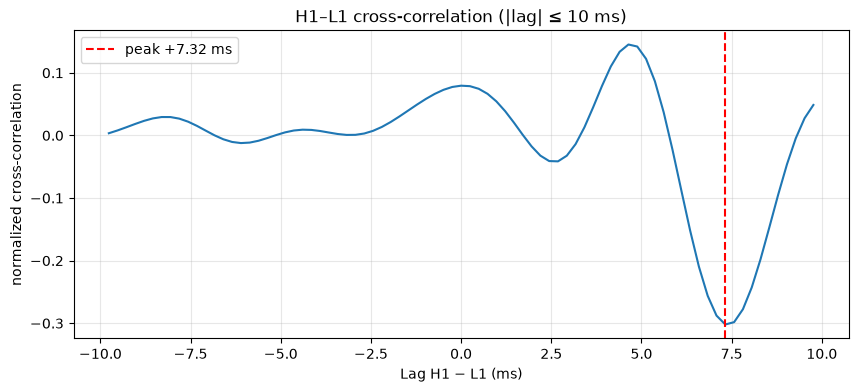

In [11]:
# 4  Direction of arrival: cross-correlate the two whitened, band-passed chirps.
# filtered_h1 and filtered_l1 come from 3.a and share the same time grid (t_h1 == t_l1).
win = np.abs(t_h1) < 0.5
a = filtered_h1[win]; a = (a - a.mean()) / a.std()
b = filtered_l1[win]; b = (b - b.mean()) / b.std()

xcorr = correlate(a, b, mode="full", method="fft") / len(a)
lags = np.arange(-len(b) + 1, len(a))              # lag > 0  ->  H1 (a) lags L1 (b)

max_lag = int(0.010 * FS)                          # physical bound: |Δt| <= d/c ~ 10 ms
sel = np.abs(lags) <= max_lag
lags_ms = lags[sel] / FS * 1000
cc = xcorr[sel]

k = int(np.argmax(np.abs(cc)))                     # abs: the detectors have opposite polarity here
delay_samples = int(lags[sel][k])
delay_seconds = delay_samples / FS
polarity = "anti-correlated" if cc[k] < 0 else "correlated"

print(f"integer peak: {delay_samples:+d} samples = {delay_seconds * 1e3:+.3f} ms  "
      f"(H1 relative to L1);  peak is {polarity}")
print(f"one sample = {1e6 / FS:.0f} us")

plt.figure(figsize=(10, 4))
plt.plot(lags_ms, cc)
plt.axvline(delay_seconds * 1000, color="red", ls="--", label=f"peak {delay_seconds * 1e3:+.2f} ms")
plt.xlabel("Lag H1 − L1 (ms)")
plt.ylabel("normalized cross-correlation")
plt.title("H1–L1 cross-correlation (|lag| ≤ 10 ms)")
plt.legend()
plt.grid(alpha=0.3)


### 4.a — Retardo

Reporten el retardo del pico y su signo: ¿qué detector recibió la señal primero?

> **Pista.** A 4096 Hz el intervalo entre muestras es de 244 µs y el retardo máximo posible es de 10 ms. Evalúen si la resolución de una muestra les alcanza.

In [12]:
# 4.a  Sub-sample refinement.
# One sample is 244 us and the Annex uncertainty is ~0.4 ms, so the integer peak
# is too coarse: interpolate the correlation around its maximum.

kk = int(np.argmax(np.abs(cc)))

# (1) Parabolic 3-point fit on |cc|
y1, y2, y3 = np.abs(cc[kk - 1]), np.abs(cc[kk]), np.abs(cc[kk + 1])
frac = 0.5 * (y1 - y3) / (y1 - 2 * y2 + y3)          # |frac| < 0.5 samples
delay_parab = (delay_samples + frac) / FS

# (2) Cross-check: FFT-upsample the correlation x16 near the peak
up = 16
seg = cc[kk - 8:kk + 9]
seg_up = np.fft.irfft(np.fft.rfft(seg), n=len(seg) * up) * up
delay_up = (delay_samples + np.argmax(np.abs(seg_up)) / up - 8) / FS

print(f"integer            : {delay_seconds * 1e3:+.3f} ms")
print(f"parabolic 3-point  : {delay_parab * 1e3:+.3f} ms   (shift {frac:+.2f} sample)")
print(f"FFT upsample x{up}   : {delay_up * 1e3:+.3f} ms")

delay_seconds = delay_parab                          # refined value used in 4.b
delay_ms = delay_seconds * 1e3
print(f"\n=> Δt = t_H1 − t_L1 = {delay_ms:+.2f} ms  ->  L1 leads H1 by {abs(delay_ms):.2f} ms")
print("   Annex: 6.9 (+0.5 / -0.4) ms")


integer            : +7.324 ms
parabolic 3-point  : +7.395 ms   (shift +0.29 sample)
FFT upsample x16   : +7.294 ms

=> Δt = t_H1 − t_L1 = +7.39 ms  ->  L1 leads H1 by 7.39 ms
   Annex: 6.9 (+0.5 / -0.4) ms


> **Respuesta.**
>
> **Retardo.** We obtain Δt = t_H1 − t_L1 = **+7.4 ms**. The positive sign means that H1 detected the signal later, so **L1 detected it first**, about 7.4 ms before H1. The integer-sample estimate and the two interpolation methods give almost the same result: +7.32 ms, +7.4 ms, and +7.29 ms.
>
> **Sign of the peak.** The correlation peak is negative because the two detectors have almost opposite orientations. Therefore, they measure the signal with opposite signs. This does not change the delay: the position of the peak tells us when the signal arrived, while its sign only tells us whether the signals point in the same or opposite directions.
>
> **Is one-sample resolution enough?** No. At 4096 Hz, one sample corresponds to 244 µs. This is not precise enough for the uncertainty we want, so we estimate the peak position between two samples using interpolation. The two methods agree within about 0.1 ms, which gives confidence in the result.
>
> **Comparison with the Annex.** Our result, 7.4 ms, is close to the published value of 6.9 ms. Both results have the same sign and are consistent within the uncertainty.

### 4.b — Ángulo de cono

Calculen el **ángulo del cono de arribo** respecto de la línea que une ambos detectores, y comparen con el Anexo:

$$\cos\theta = \frac{c\,\Delta t}{d}$$

¿Por qué el resultado es un cono y no una dirección? ¿Qué haría falta para localizar la fuente en un punto?

In [13]:
# 4.b  Cone angle relative to the H1-L1 baseline.
c = 299_792_458          # m/s
d = 3002e3               # m   (H1-L1 separation)

cos_theta = np.clip(c * delay_seconds / d, -1.0, 1.0)   # delay_seconds = t_H1 - t_L1 (from 4.a)
theta_deg = np.degrees(np.arccos(cos_theta))

print(f"Δt = {delay_seconds * 1e3:+.2f} ms   (max possible d/c = {d / c * 1e3:.2f} ms)")
print(f"cos(theta) = {cos_theta:.3f}")
print(f"theta = {theta_deg:.1f} deg  measured from the H1 -> L1 baseline direction")


Δt = +7.39 ms   (max possible d/c = 10.01 ms)
cos(theta) = 0.738
theta = 42.4 deg  measured from the H1 -> L1 baseline direction


> **Respuesta.**
>
> **Result.** cos θ = c·Δt/d ≈ 0.74 → **θ ≈ 42°** from the H1→L1 baseline. Because L1 was hit first,
> the source lies on the L1 side of the baseline.
>
> **Why a cone and not a direction.** The time difference tells us only the angle between the source and the line joining H1 and L1. If we keep this angle fixed at θ and rotate the possible source direction around that line, the directions form a **cone**. Therefore, with only two detectors, we cannot determine one exact direction.
>
> **To localize to a point.** Add at least a third, non-collinear detector: each pair of
> detectors gives its own cone, and three cones generically intersect in two points, reduced to one by
> the antenna-pattern amplitudes and phases and by requiring a consistent inspiral waveform.

---

## Anexo: valores de referencia

<details>
<summary><b>⚠️ No abrir antes de haber completado los puntos correspondientes — clic para desplegar</b></summary>

<br>

Sirve para **contrastar** sus resultados, no para orientarlos. Fuente: Abbott et al., *Observation of Gravitational Waves from a Binary Black Hole Merger*, Phys. Rev. Lett. 116, 061102 (2016).

**Evento** (puntos 2 y 3). GW150914 ocurrió el 14/09/2015 a las 09:50:45 UTC, GPS 1126259462,4. La señal barre de ~35 Hz a ~250 Hz en unos 0,2 s, completando unos 8 ciclos, con un *strain* pico de 1,0 &times; 10<sup>-21</sup>.

**Sensibilidad** (punto 2.e). En la corrida O1, la amplitud espectral de ruido de ambos detectores alcanzó un mínimo del orden de 10<sup>-23</sup> Hz<sup>-1/2</sup> entre ~100 y ~300 Hz, degradándose rápidamente por debajo de 20 Hz.

**Retardo y localización** (punto 4). L1 registró el evento 6,9 (+0,5 / −0,4) ms **antes** que H1. Con solo dos detectores, la región de credibilidad al 90 % abarcó unos 600 grados cuadrados.

</details>

---

## Extensiones opcionales

Para quienes quieran ir más allá: mostrar el evento en un **espectrograma**; verificar la hipótesis de **gaussianidad** del ruido, que es distinta de la de estacionariedad; usar las máscaras `DQmask` e `injmask` de los archivos para descartar tramos no utilizables e inyecciones de prueba; estimar el retardo con precisión **sub-muestral** y propagar la incertidumbre hasta $\theta$; explicar el signo del pico de correlación cruzada a partir de la orientación relativa de los brazos de ambos detectores.